<>:70: SyntaxWarning: invalid escape sequence '\s'
<>:70: SyntaxWarning: invalid escape sequence '\s'
C:\Users\luiz.melo\AppData\Local\Temp\ipykernel_29076\3022380236.py:70: SyntaxWarning: invalid escape sequence '\s'
  axs[i, 1].text(0.98, 0.95, f'Ruído $\sigma^2 = {sigma2}$',


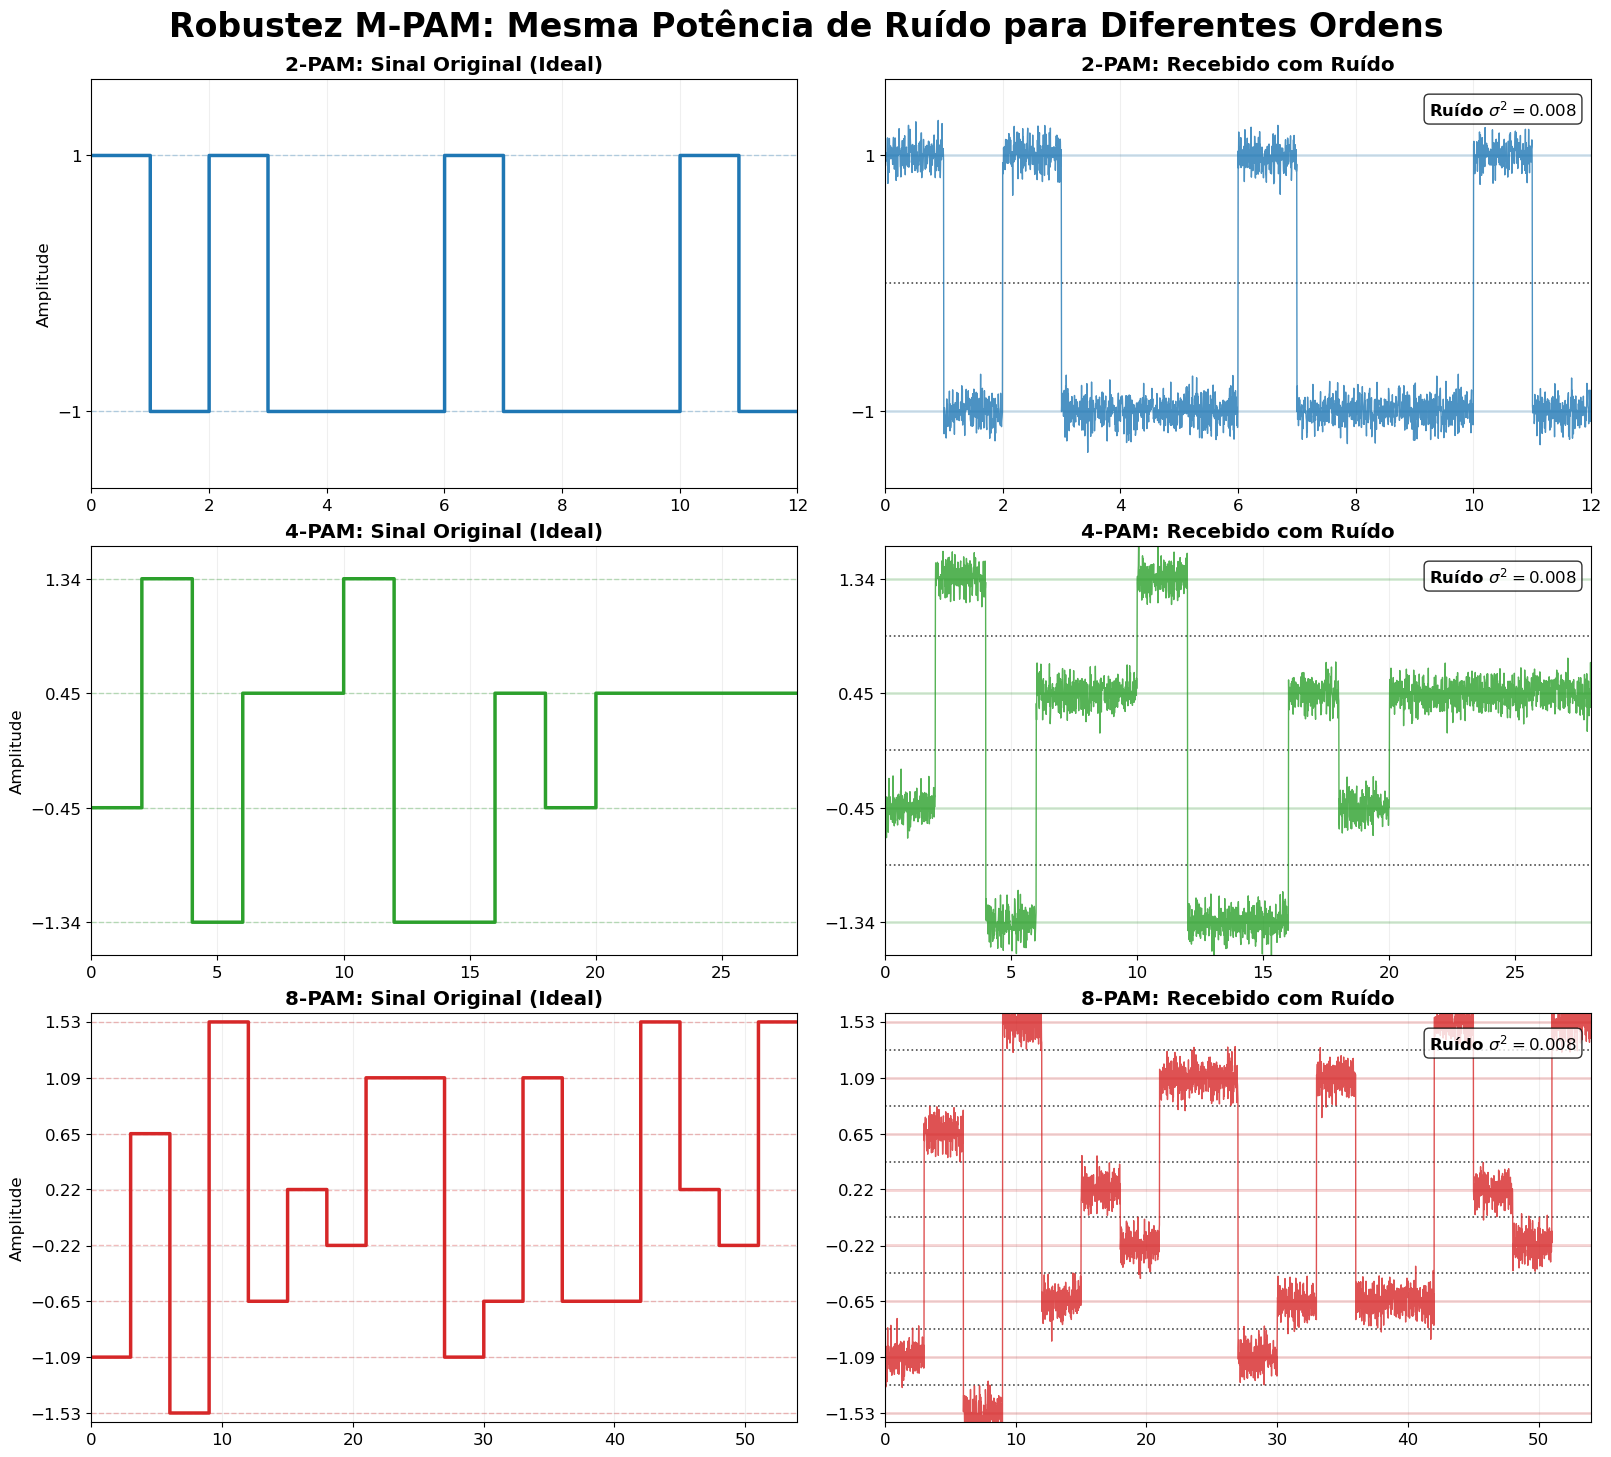

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Estilo para slides
plt.rcParams.update({'font.size': 12, 'axes.grid': True, 'grid.alpha': 0.2})

# Parâmetros
Rb = 1.0           
fs = 200
orders = [2, 4, 8]
colors = ['#1f77b4', '#2ca02c', '#d62728']

# Parâmetro de Ruído (Mesma variância para todos os casos)
sigma2 = 0.008  

fig, axs = plt.subplots(3, 2, figsize=(16, 14), constrained_layout=True)
fig.suptitle('Robustez M-PAM: Mesma Potência de Ruído para Diferentes Ordens', 
             fontsize=24, fontweight='bold', y=1.03)

for i, M in enumerate(orders):
    k = int(np.log2(M))
    Ts = k / Rb

    # 1) Níveis Normalizados (Potência Média P = 1)
    levels = np.arange(-(M - 1), M, 2).astype(float)
    scale = np.sqrt(3 / (M**2 - 1))
    target_levels = levels * scale

    # 2) Sequência com todos os níveis embaralhados
    np.random.seed(42)
    shuffled_targets = np.random.permutation(target_levels)
    actual_symbols = np.concatenate((shuffled_targets, np.random.choice(target_levels, size=10)))
    
    # 3) Geração das formas de onda
    wave_ideal = np.repeat(actual_symbols, fs)
    t_wave = np.linspace(0, len(actual_symbols) * Ts, len(wave_ideal))
    
    # Adição de Ruído AWGN
    noise = np.random.normal(0, np.sqrt(sigma2), len(wave_ideal))
    wave_noisy = wave_ideal + noise

    # 4) Limites de Decisão (Thresholds)
    thresholds = (target_levels[:-1] + target_levels[1:]) / 2

    # --- COLUNA 1: SINAL IDEAL ---
    for lvl in target_levels:
        axs[i, 0].axhline(lvl, color=colors[i], linestyle='--', alpha=0.3, lw=1)
    
    axs[i, 0].step(t_wave, wave_ideal, where='post', color=colors[i], lw=2.5)
    axs[i, 0].set_title(f'{M}-PAM: Sinal Original (Ideal)', fontweight='bold')
    axs[i, 0].set_ylabel('Amplitude')
    axs[i, 0].set_ylim(-1.6, 1.6)
    axs[i, 0].set_yticks(np.round(target_levels, 2))
    axs[i, 0].set_xlim(0, t_wave[-1])

    # --- COLUNA 2: SINAL COM RUÍDO ---
    # Fundo com níveis e decisões
    for lvl in target_levels:
        axs[i, 1].axhline(lvl, color=colors[i], linestyle='-', alpha=0.2, lw=2)
    for th in thresholds:
        axs[i, 1].axhline(th, color='black', linestyle=':', alpha=0.7, lw=1.2)

    axs[i, 1].plot(t_wave, wave_noisy, color=colors[i], lw=1, alpha=0.8)
    axs[i, 1].set_title(f'{M}-PAM: Recebido com Ruído', fontweight='bold')
    axs[i, 1].set_ylim(-1.6, 1.6)
    axs[i, 1].set_yticks(np.round(target_levels, 2))
    axs[i, 1].set_xlim(0, t_wave[-1])

    # Anotação da Variância do Ruído
    axs[i, 1].text(0.98, 0.95, f'Ruído $\sigma^2 = {sigma2}$', 
                   transform=axs[i, 1].transAxes, 
                   va='top', ha='right', fontsize=12, fontweight='bold',
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='black'))

plt.savefig('mpam_comparativo_ruido_sigma.png', dpi=300, bbox_inches='tight')
plt.show()